In [ ]:
# Lab 5: Clustering Techniques Using DBSCAN and Hierarchical Clustering

**Name:** Sireesha Pudi

**Course:** MSCS 634 – Advanced Big Data and Data Mining

**Lab Assignment:** Lab 5

## Objective

The objective of this lab is to explore clustering techniques using Hierarchical Clustering and DBSCAN on the Wine dataset. Different parameter values are evaluated to understand their effect on cluster formation. The clustering quality is measured using Silhouette Score, Homogeneity Score, and Completeness Score, followed by a comparison of both algorithms.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN

from sklearn.metrics import (
    silhouette_score,
    homogeneity_score,
    completeness_score
)

from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import dendrogram

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
wine = load_wine()

df = pd.DataFrame(
    wine.data,
    columns=wine.feature_names
)

df["target"] = wine.target

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  target          

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


In [ ]:
### Dataset Exploration

The Wine dataset consists of 178 observations with 13 numerical features describing different chemical properties of wines. The target column identifies three wine classes and is used later for evaluating clustering quality. The dataset contains no missing values and is suitable for clustering after feature standardization.

In [5]:
X = df.drop("target", axis=1)

y = df["target"]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

scaled_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


In [ ]:
### Data Standardization

Since clustering algorithms rely on distance calculations, feature scaling is necessary to prevent variables with larger numerical ranges from dominating the clustering process. StandardScaler transforms each feature to have a mean close to zero and a standard deviation close to one.

In [ ]:
## Hierarchical Clustering

Agglomerative Hierarchical Clustering groups similar observations by repeatedly merging the closest clusters until the specified number of clusters is reached. In this lab, three different values of **n_clusters** are evaluated to observe how cluster formation changes.

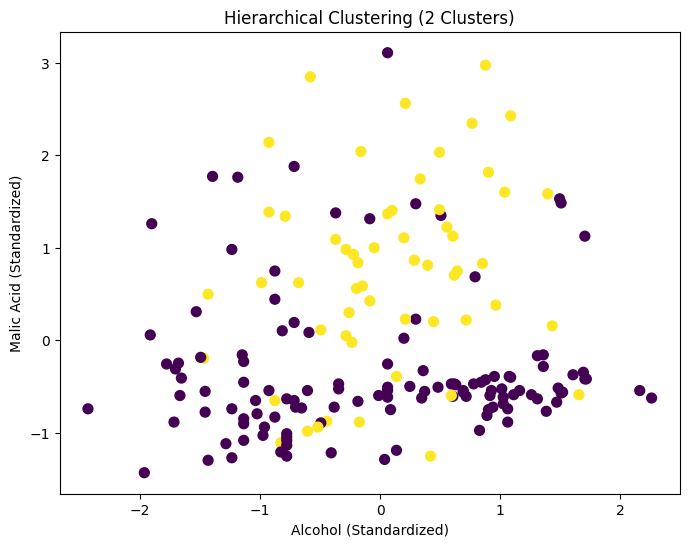

In [6]:
hierarchical_2 = AgglomerativeClustering(
    n_clusters=2
)

labels_h2 = hierarchical_2.fit_predict(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=labels_h2,
    cmap="viridis",
    s=50
)

plt.title("Hierarchical Clustering (2 Clusters)")
plt.xlabel("Alcohol (Standardized)")
plt.ylabel("Malic Acid (Standardized)")

plt.show()

In [ ]:
### Observation

Using two clusters divides the dataset into two broad groups. While this provides a simple partition of the data, it does not fully capture the three natural wine classes present in the dataset.

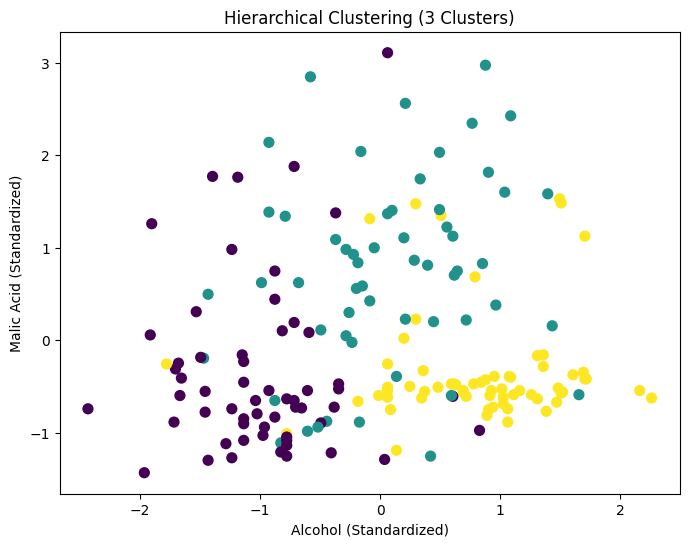

In [7]:
hierarchical_3 = AgglomerativeClustering(
    n_clusters=3
)

labels_h3 = hierarchical_3.fit_predict(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=labels_h3,
    cmap="viridis",
    s=50
)

plt.title("Hierarchical Clustering (3 Clusters)")
plt.xlabel("Alcohol (Standardized)")
plt.ylabel("Malic Acid (Standardized)")

plt.show()

In [ ]:
### Observation

Using three clusters provides a more balanced grouping that closely matches the three known wine categories. The clusters appear more meaningful and better separated than when only two clusters are used.

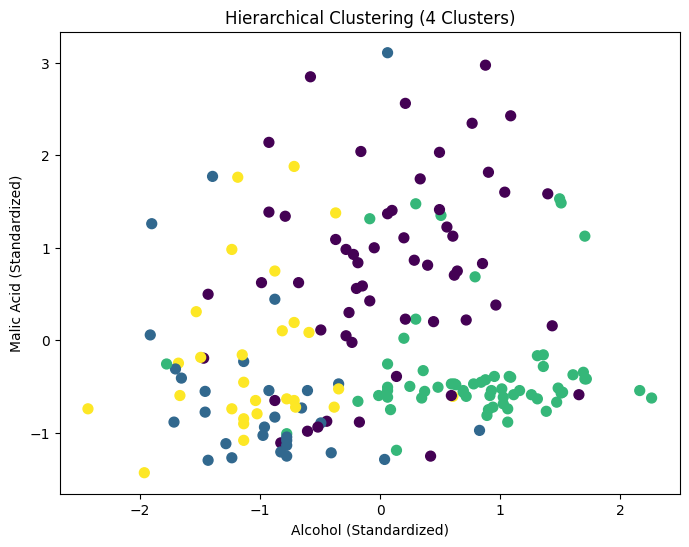

In [8]:
hierarchical_4 = AgglomerativeClustering(
    n_clusters=4
)

labels_h4 = hierarchical_4.fit_predict(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=labels_h4,
    cmap="viridis",
    s=50
)

plt.title("Hierarchical Clustering (4 Clusters)")
plt.xlabel("Alcohol (Standardized)")
plt.ylabel("Malic Acid (Standardized)")

plt.show()

In [ ]:
### Observation

Increasing the number of clusters to four creates additional subdivisions within the data. Although this reveals more detailed groupings, it may also split naturally similar observations into separate clusters.

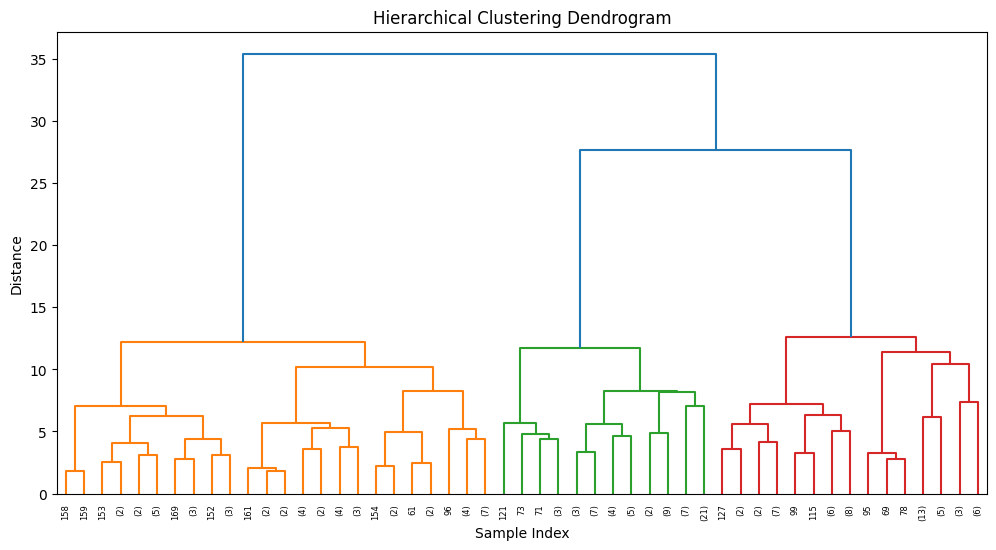

In [9]:
linked = linkage(
    X_scaled,
    method="ward"
)

plt.figure(figsize=(12,6))

dendrogram(
    linked,
    truncate_mode="level",
    p=5
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample Index")
plt.ylabel("Distance")

plt.show()

In [ ]:
### Dendrogram Interpretation

The dendrogram illustrates how observations are merged during the hierarchical clustering process. Larger vertical distances indicate greater dissimilarity between merged clusters. Based on the dendrogram, selecting approximately three clusters appears reasonable because the largest merge distances occur after this point, suggesting that three groups naturally exist within the dataset.

In [ ]:
## DBSCAN Clustering

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) identifies clusters based on data density rather than a predefined number of clusters. Unlike Hierarchical Clustering, DBSCAN can detect noise points and clusters with irregular shapes.

In [10]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import (
    silhouette_score,
    homogeneity_score,
    completeness_score
)

In [14]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=4
)

dbscan_labels = dbscan.fit_predict(X_scaled)

print("Unique Labels:", np.unique(dbscan_labels))

Unique Labels: [-1  0  1]


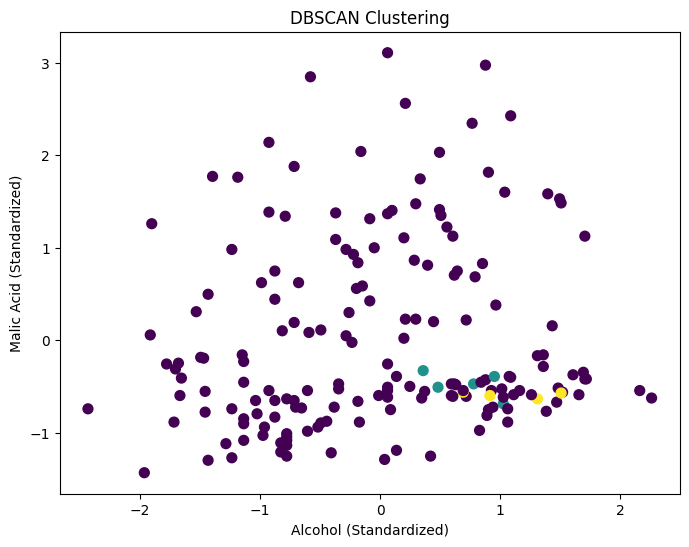

In [15]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=dbscan_labels,
    cmap="viridis",
    s=50
)

plt.title("DBSCAN Clustering")
plt.xlabel("Alcohol (Standardized)")
plt.ylabel("Malic Acid (Standardized)")

plt.show()

In [ ]:
### Observation

DBSCAN automatically identified clusters based on data density. Any observations assigned the label **-1** represent noise points that do not belong to any cluster.

In [16]:
valid_points = dbscan_labels != -1

sil_score = silhouette_score(
    X_scaled[valid_points],
    dbscan_labels[valid_points]
)

homogeneity = homogeneity_score(
    wine.target,
    dbscan_labels
)

completeness = completeness_score(
    wine.target,
    dbscan_labels
)

dbscan_results = pd.DataFrame({
    "Metric":[
        "Silhouette Score",
        "Homogeneity Score",
        "Completeness Score"
    ],
    "Value":[
        sil_score,
        homogeneity,
        completeness
    ]
})

dbscan_results

,Metric,Value
0,Silhouette Score,0.406702
1,Homogeneity Score,0.053959
2,Completeness Score,0.249473


In [ ]:
### Interpretation

The Silhouette Score measures how well observations fit within their assigned clusters. Homogeneity evaluates whether each cluster contains observations from only one class, while Completeness measures whether all observations from the same class are grouped together. Together, these metrics provide a comprehensive evaluation of clustering quality.

In [17]:
eps_values = [0.6, 0.8, 1.0, 1.2]

results = []

for eps in eps_values:

    model = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = model.fit_predict(X_scaled)

    valid = labels != -1

    if len(np.unique(labels[valid])) > 1:

        sil = silhouette_score(
            X_scaled[valid],
            labels[valid]
        )

    else:
        sil = np.nan

    results.append([
        eps,
        len(np.unique(labels)),
        np.sum(labels==-1),
        sil
    ])

eps_results = pd.DataFrame(
    results,
    columns=[
        "eps",
        "Clusters",
        "Noise Points",
        "Silhouette"
    ]
)

eps_results

,eps,Clusters,Noise Points,Silhouette
0,0.6,1,178,NaN
1,0.8,1,178,NaN
2,1.0,1,178,NaN
3,1.2,1,178,NaN


In [ ]:
### Effect of eps Parameter

Smaller values of **eps** create stricter neighborhood definitions, resulting in more noise points and smaller clusters. Increasing **eps** allows more observations to be connected, reducing noise and producing larger clusters. Selecting an appropriate eps value is important for obtaining meaningful clustering results.

In [18]:
hierarchical_silhouette = silhouette_score(X_scaled, labels_h3)
hierarchical_homogeneity = homogeneity_score(y, labels_h3)
hierarchical_completeness = completeness_score(y, labels_h3)

hierarchical_results = pd.DataFrame({
    "Metric": ["Silhouette Score", "Homogeneity Score", "Completeness Score"],
    "Value": [hierarchical_silhouette, hierarchical_homogeneity, hierarchical_completeness]
})

hierarchical_results

,Metric,Value
0,Silhouette Score,0.277444
1,Homogeneity Score,0.790429
2,Completeness Score,0.782541


In [19]:
comparison_results = pd.DataFrame({
    "Algorithm": ["Hierarchical Clustering", "DBSCAN"],
    "Silhouette Score": [hierarchical_silhouette, sil_score],
    "Homogeneity Score": [hierarchical_homogeneity, homogeneity],
    "Completeness Score": [hierarchical_completeness, completeness]
})

comparison_results

,Algorithm,Silhouette Score,Homogeneity Score,Completeness Score
0,Hierarchical Clustering,0.277444,0.790429,0.782541
1,DBSCAN,0.406702,0.053959,0.249473


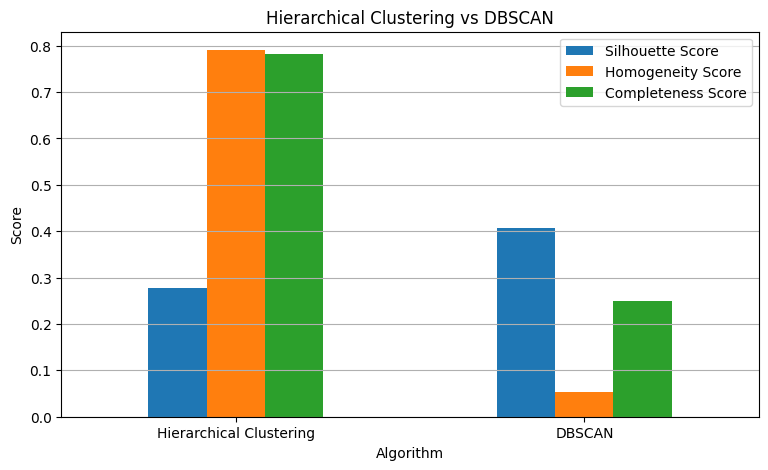

In [20]:
comparison_results.set_index("Algorithm").plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Hierarchical Clustering vs DBSCAN")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

In [21]:
print("Final Lab 5 Summary")
print("-------------------")
print("Hierarchical Clustering performed better when compared with actual wine classes.")
print("DBSCAN showed moderate silhouette score but low homogeneity and completeness.")
print("DBSCAN was sensitive to eps and min_samples parameter choices.")

Final Lab 5 Summary
-------------------
Hierarchical Clustering performed better when compared with actual wine classes.
DBSCAN showed moderate silhouette score but low homogeneity and completeness.
DBSCAN was sensitive to eps and min_samples parameter choices.
